Decision Matrix


,Accuracy,InferenceTime,ModelSize,ComputeCost,Generalization
SBERT,92,120,420,3,91
USE,90,140,500,3,89
MiniLM,89,60,120,1,88
MPNet,93,130,450,3,92
DistilBERT,88,70,250,2,87



TOPSIS Result


,TOPSIS_Score,Rank
MiniLM,0.938004,1.0
DistilBERT,0.675045,2.0
SBERT,0.202777,3.0
MPNet,0.133399,4.0
USE,0.031956,5.0


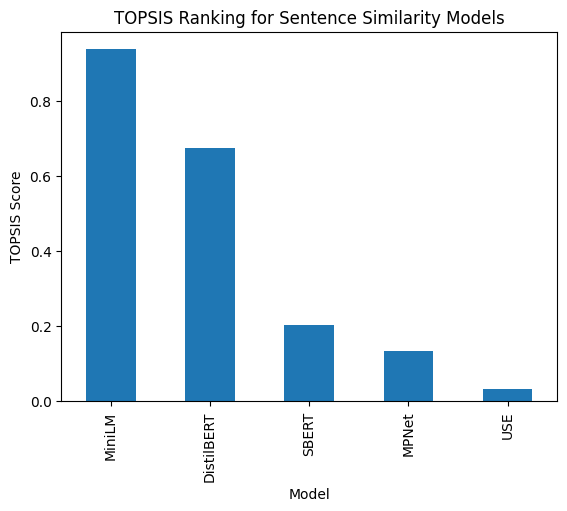

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

models = ["SBERT", "USE", "MiniLM", "MPNet", "DistilBERT"]

data = pd.DataFrame({
    "Accuracy": [92, 90, 89, 93, 88],
    "InferenceTime": [120, 140, 60, 130, 70],
    "ModelSize": [420, 500, 120, 450, 250],
    "ComputeCost": [3, 3, 1, 3, 2],
    "Generalization": [91, 89, 88, 92, 87]
}, index=models)

print("Decision Matrix")
display(data)

weights = np.array([0.30, 0.20, 0.15, 0.15, 0.20])

norm = data / np.sqrt((data ** 2).sum())

weighted = norm * weights

benefit = ["Accuracy", "Generalization"]
cost = ["InferenceTime", "ModelSize", "ComputeCost"]

ideal_best = []
ideal_worst = []

for col in weighted.columns:
    if col in benefit:
        ideal_best.append(weighted[col].max())
        ideal_worst.append(weighted[col].min())
    else:
        ideal_best.append(weighted[col].min())
        ideal_worst.append(weighted[col].max())

ideal_best = np.array(ideal_best)
ideal_worst = np.array(ideal_worst)

d_plus = np.sqrt(((weighted - ideal_best) ** 2).sum(axis=1))
d_minus = np.sqrt(((weighted - ideal_worst) ** 2).sum(axis=1))

score = d_minus / (d_plus + d_minus)

result = pd.DataFrame({
    "TOPSIS_Score": score,
    "Rank": score.rank(ascending=False)
}).sort_values("TOPSIS_Score", ascending=False)

print("\nTOPSIS Result")
display(result)

plt.figure()
result["TOPSIS_Score"].plot(kind="bar")
plt.ylabel("TOPSIS Score")
plt.xlabel("Model")
plt.title("TOPSIS Ranking for Sentence Similarity Models")
plt.show()